**Punkte**

| Aufgabe 1 | Aufgabe 2 | Aufgabe 3 |
|-----------|-----------|-----------|
|           |           |           |
|     / 35  |     / 50  |     / 15  |
|           |           |           |

Gesamtpunktzahl:

___

# Allgemeine Hinweise zur Klausur 63123 **Data Engineering für Data Science**
> **_NOTE:_**  *Bitte lesen Sie sich diese Hinweise vor der Bearbeitung der Klausur aufmerksam durch.*

- Die **Klausurdauer** beträgt **2 Stunden**.
- Bevor Sie mit der Bearbeitung der Klausuraufgaben beginnen, tragen Sie bitte Ihre(n) **Nachnamen**, Ihre(n) **Vornamen** und Ihre **Matrikelnummer** in die vorgesehenen Felder (oben) ein.
- Wie schon in den Übungsaufgaben erfolgt die Bearbeitung in zwei unterschiedliche Zell-Typen: In **Code-Zellen** sollen Sie (Python-)Code (bei Bedarf kommentiert) einfügen und ausführen. In **Raw-Zellen** erwarten wir eine Antwort in Textform.
- Sollten bestimmte Fakten aus Ihrer Sicht nicht eindeutig formuliert sein, so schreiben Sie Ihre Annahmen zur Lösung dazu.
- Denken Sie bei Plots an Titel, Achsenbeschriftung und bei Bedarf Legende.
- Es empfiehlt sich, das Notebook, bzw. das daraus generierte PDF in regelmäßigen Abständen zu sichern. So müssen Sie nicht bei Null anfangen, sollte es unerwartetere Weise zu Software-Problemen kommen.
- Bitte beachten Sie die Liste der erlaubten Hilfsmittel, die in den Prüfungsinformationen angegeben ist.
- Es werden nur Lösungsabgaben im PDF-Format akzeptiert. Diese müssen mit der vom Lehrgebiet bereitgestellten Software-Umgebung über `File -> Download as -> PDF via LaTeX (.pdf)` oder dem entsprechenden Konsolenaufruf erzeugt worden sein.


# Die Welt der Brettspiel-Daten
Stellen Sie sich vor, Sie betreten ein gemütliches Spiele-Café voller Regale mit Brettspielen – von strategischen Meisterwerken über kooperative Abenteuer bis hin zu schnellen Partyspielen. Gäste kommen zusammen, um neue Spiele auszuprobieren, ihre Favoriten zu bewerten und Empfehlungen auszusprechen. Doch wo gibt es solche Spiele-Cafés? Welche Spiele stehen dort zur Verfügung? Welche Spiele sind tatsächlich die beliebtesten? Welche Genres ziehen die meisten Spielenden an? Und wie beeinflussen Bewertungen die Entscheidungen der Gäste?

Um solche Fragen beantworten zu können, ist es wichtig, die Daten hinter den Spielen zu verstehen und sinnvoll zu speichern und auszuwerten, worum sich die internationale Brettspielevereinigung (International Board Game Studies Association - IBGSA) kümmert. In dieser Klausur tauchen Sie in genau diese Welt ein: Sie sollen die Daten über Spiele-Cafés und Brettspiele optimal speichern, bereinigen und analysieren. Dafür stehen Ihnen neben diesem Notebook die folgenden Dateien zur Verfügung:
- `ibgsa-app-db-design.pdf`: Eine PDF mit unterschiedlichen Datenmodellen - diese wird für **ausschließlich für Aufgabe 1** benötigt.
- `spiele-cafe.pdf`: Eine PDF mit Informationen über ein konkretes Spiele-Café in Pixhagen - diese wird für **ausschließlich für Aufgabe 2** benötigt.
- `data.csv`: Zu verarbeitende Daten - diese werden **ausschließlich für Aufgabe 2** benötigt.

Viel Erfolg!

___

In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import iplantuml

<div class="alert alert-block alert-danger">

Diese Zelle bitte auf keinen Fall löschen, da der Seitenumbruch für die Korrektur benötigt wird.
    
\newpage

</div>

## Aufgabe 1 - Modellierung, NoSQL (35 Punkte)

Die internationale Brettspielevereinigung (IBGSA) erfreut sich immer größerer Beliebtheit. Um die stetig wachsende Anzahl teilnehmender Cafés und abgegebener Ratings bewältigen zu können, wird eine neue Webanwendung entwickelt. Den Kern dieser Anwendung stellt das Datenbanksystem dar. Das Entwicklerteam hat bereits mehrere Designvorschläge für Cassandra und MongoDB bereitgestellt. Hier gilt es nun das am besten geeignete Design auszuwählen. 

Da sich ein anderes Team um interne Schnittstellen für das Hinzufügen weiterer Brettspiele oder das nächtliche Update aggregierter Daten (wie die durchschnittliche Bewertung von Brettspielen) kümmert, können solche Aspekte vernachlässigt werden.

In der vorliegenden Aufgabe sollen Sie der IBGSA helfen, das am besten geeignete Design auszuwählen. Dafür steht Ihnen neben diesem Notebook die folgende Datei zur Verfügung:
- `ibgsa-app-db-design.pdf`: Eine PDF mit den verschiedenen Designvorschlägen und geplanten Abfragen

### Aufgabe 1.1 Abfragen (5 Punkte)

<div class="alert alert-block alert-info">

Beschreiben Sie die Funktion und das zu erwartende Ergebnis der nachfolgenden Abfragen. Die Abfragen beziehen sich auf die Schemata in der Datei `ibgsa-app-db-design.pdf`.
</div>

**Abfrage 1 (Cassandra)**

```text
SELECT
    AVG(rating)
FROM
    rating_by_date_bucket
WHERE
    day=27 AND
    month=8 AND
    year=2025 AND
    board_game_id="b4e8a1c9-3f2d-4e1c-a5d6-7c8fbd6f8142"
```

**Abfrage 2 (MongoDB)**

```text
db.Board_Game.aggregate(
    [
        {
            "$match": {
                "cafe_ids": { $in: ["652c1a8f5e7d9b3c4f0e1234"] }
            }
        },
        {
            "$lookup": {
                "from": "Type",
                "localField": "type_id",
                "foreignField": "id",
                "as": "types"
            }
        },
        {
            $addFields: {
                type: { $arrayElemAt: ["$types.type", 0] } 
            }
        },
        {
            "$project: {
                "name": 1,
                "type": 1
            }
        }
    ]
);
```

### Aufgabe 1.2 Cassandra (15 Punkte)

<div class="alert alert-block alert-info">
    
Wählen Sie das für <b>Cassandra</b> am besten geeignete Schema aus. Die geplanten Abfragen und Schemavarianten befinden sich in der Datei `ibgsa-app-db-design.pdf`. Bezüglich der beiden nicht ausgewählten Schemavarianten: Ordnen Sie die nachfolgend gegebenen Tags den einzelnen Abfragen zu. Abfragen können keine oder mehrere Tags zugeordnet werden. Geben Sie dabei jeweils an, auf welche Variante Sie sich beziehen.
</div>

Tags: 
- `GeoIndex-Problem`
- `Partition-Size-Problem`
- `JOIN/Multiple-Queries-Notwendig` 
- `Count/Aggregation/Computation-Notwendig`
- `Growing-Array-Problem`

#### Cassandra, Auswahl des besten Schemavorschlags (3 Punkte)

"Kreuzen" Sie in der folgenden Raw-Zelle das aus Ihrer Sicht am besten geeignete Schema an.

#### Cassandra, wesentliche Nachteile des 1. nicht ausgewählten Schemas (6 Punkte)

Ordnen Sie die vorgegebenen Tags den einzelnen Abfragen zu. 

Im Folgenden finden Sie ein Beispiel solch einer Zuordnung:

```text
Nachteile zu Variante: 1

- Q1: "Count/Aggregation/Computation-Notwendig"; "JOIN/Multiple-Queries-Notwendig"
- Q2:
- Q3: "GeoIndex-Problem"
- Q4:
```

#### Cassandra, wesentliche Nachteile des 2. nicht ausgewählten Schemas (6 Punkte)

Gleiches Vorgehen wie beim 1. nicht gewählten Schema.

### Aufgabe 1.3 MongoDB (15 Punkte)

<div class="alert alert-block alert-info">
    
Wählen Sie das für <b>MongoDB</b> am besten geeignete Schema aus. Die geplanten Abfragen und Schemavarianten befinden sich in der Datei `ibgsa-app-db-design.pdf`. Bezüglich der beiden nicht ausgewählten Schemavarianten: Ordnen Sie die nachfolgend gegebenen Tags den einzelnen Abfragen zu. Abfragen können keine oder mehrere Tags zugeordnet werden. Geben Sie dabei jeweils an, auf welche Variante Sie sich beziehen.
</div>

Tags: 
- `GeoIndex-Problem`
- `Partition-Size-Problem`
- `JOIN/Multiple-Queries-Notwendig` 
- `Count/Aggregation/Computation-Notwendig`
- `Growing-Array-Problem`

#### MongoDB, Auswahl des besten Schemavorschlags (3 Punkte)

"Kreuzen" Sie in der folgenden Raw-Zelle das aus Ihrer Sicht am besten geeignete Schema an.

#### MongoDB, wesentliche Nachteile des 1. nicht ausgewählten Schemas (6 Punkte)

Ordnen Sie die vorgegebenen Tags den einzelnen Abfragen zu. 

Im Folgenden finden Sie ein Beispiel solch einer Zuordnung:

```text
Nachteile zu Variante: 1

- Q1: "GeoIndex-Problem"; "Count/Aggregation/Computation-Notwendig"
- Q2: "Growing-Array-Problem"
- Q3:
- Q4:
```

#### MongoDB, wesentliche Nachteile des 2. nicht ausgewählten Schemas (6 Punkte)

Gleiches Vorgehen wie beim 1. nicht gewählten Schema.

<div class="alert alert-block alert-danger">

Diese Zelle bitte auf keinen Fall löschen, da der Seitenumbruch für die Korrektur benötigt wird.
    
\newpage

</div>

## Aufgabe 2 - Datenvorverarbeitung und Datenqualität (50 Punkte)
Willkommen im Spiele-Café Pix & Brett in Pixhagen! Hier treffen sich Jung und Alt, Strategen und Würfelheldinnen, Regelfüchse und Erklärbären, um gemeinsam neue Brettspiele auszuprobieren, Klassiker neu zu entdecken – und gelegentlich bei der Punktewertung lautstark zu diskutieren. Gegründet wurde das Café von den Geschwistern Sachin und Sumaya Stafford, die schon als Kinder begeistert mit ihren Großeltern lange Spielenachmittage verbracht haben. Ihre Vision: Einen Ort zu schaffen, an dem Menschen verschiedenster Hintergründe zusammenkommen – wo Spielfreude, Austausch und eine gemütliche Atmosphäre im Mittelpunkt stehen.

Um die Spielauswahl stetig zu verbessern und Trends zu erkennen, erfasst das Café Bewertungen zu allen gespielten Spielen. Die Bewertung erfolgt freiwillig – jede Spieleverpackung ist mit einem entsprechenden QR-Code ausgestattet. Bisher wurden diese Bewertungen lediglich erfasst, aber nicht weiter analysiert. Nachdem im Juli 2025 aber die insgesamt 2000. Spiele-Bewertung erfolgte, wollen Sachin und Sumaya das zum Anlass nehmen, sich näher mit diesen Daten zu befassen. Sie denken auch über einen Beitritt in die IBGSA nach. Folgende Fragen wollen Sie zunächst mit den Daten beantworten:
- Welcher Spiele-Typ ist am besten bewertet?
- Nehmen die Anzahl Bewertungen über die Zeit zu oder ab?
- Welcher Spiele-Typ ist für die wenigsten Altersgruppen geeignet?
- Von welchem Spiele-Typ gibt es die meisten Spiele?
- Bei welchem Spiel wird der Glücksfaktor am höchsten eingeschätzt?
- Bei welchem Spiele-Typ wird die Spieldauer am längsten eingschätzt?
- Welches Spiel wird als leichtestes bewertet?

In der vorliegenden Aufgabe sollen Sie Sachin und Sumaya helfen, die Daten zu bereinigen und zu analysieren. Dafür stehen Ihnen neben diesem Notebook die folgenden Dateien zur Verfügung:
- `spiele-cafe.pdf`: Eine PDF mit zusätzlichen Informationen
- `data.csv`: Zu verarbeitende Daten

### Aufgabe 2.1 Datenerhebung (4 Punkte)

Im Folgenden ist ein Screenshot der Bewertungsseite gezeigt, auf die man gelangt, wenn man den entsprechenden QR-Code auf der Verpackung einscannt. 

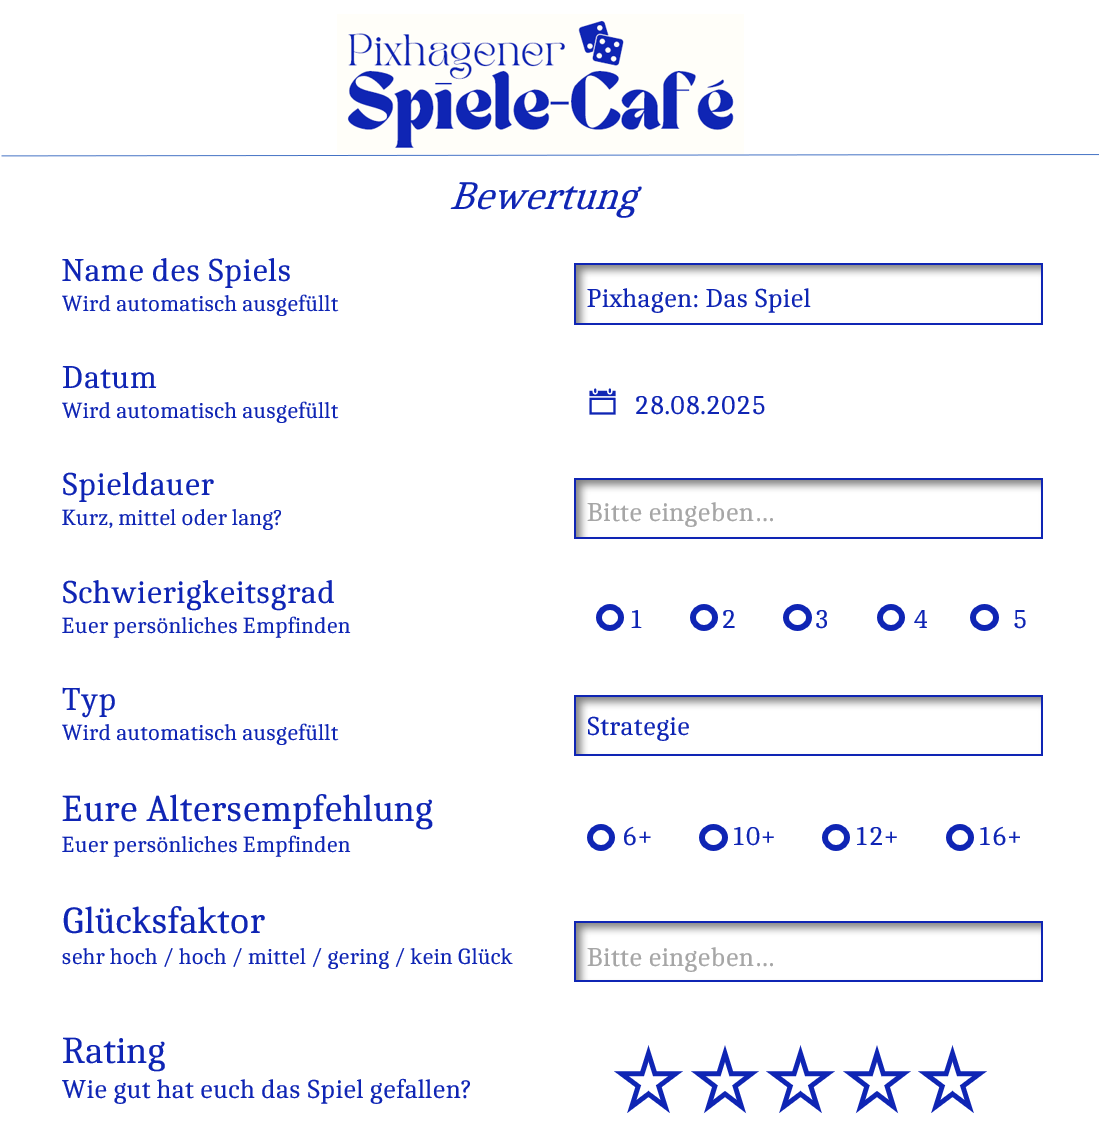

Während der *Name des Spiels* und der zugehörige *Typ* sowie das *Datum der Bewertung* automatisch ausgefüllt werden (entsprechend dem QR-Code), soll die *Dauer des Spiels*, der *Schwierigkeitsgrad* und der *Glücksfaktor* von den Bewertenden nach persönlichem Empfinden eingeschätzt werden. Ebenso soll eine *Altersempfehlung* abgegeben werden, damit diese im Nachhinein mit der Empfehlung des Herstellers abgeglichen werden kann. Außerdem soll ein *Rating* abgegeben werden, wie gut das Spiel insgesamt gefallen hat.

Sachin und Sumaya haben eine KI über mögliche Probleme bei der Datenerhebung befragt und folgende Antwort bekommen:
> "*Die beschriebene Datenerhebung könnte zu **inkonsistenten Daten** führen, also **Variationen in der Formatierung oder Struktur von Daten zwischen verschiedenen Bewertungen**.*"

<div class="alert alert-block alert-info">
    
Beurteilen Sie die Datenerhebung. Wo könnte es zu Inkonsistenzen in den Daten kommen?
- Nennen Sie zwei Felder, bei denen die Umsetzung zu Inkonsistenzen in den Daten führen könnte und nennen Sie ein Beispiel für eine mögliche Inkonsistenz.
- Geben Sie an, wie man es besser umsetzen könnte.
- Begründen Sie jeweils Ihre Aussage!
</div>

### Aufgabe 2.2 Daten laden (1 Punkt)
Als nächstes werden die benötigten Daten geladen.
<div class="alert alert-block alert-info">
    
Laden Sie die Daten (`data.csv`) in ein DataFrame namens `df`, so dass der Index rein numerisch und eindeutig ist.
</div>

In [6]:
# Ihre Lösung

df = pd.read_csv("data.csv")

df.head()

,Name,Datum,Spieldauer,Schwierigkeitsgrad,Typ,Altersempfehlung,Glücksfaktor,Rating
0,Klapperknochen-Kapitäne,2025-06-16,kurz,2,Kinder,6+,sehr hoch,1
1,Planet Würfelstein,2025-02-06,lang,4,Strategie,16+,kein Glück,4
2,Honigkrieg,2025-04-30,mittel,2,Familie,6+,gering,5
3,Meadow,2022-06-02,kurz,3,Familie,10+,sehr hoch,5
4,Sleeping Gods,2025-01-08,lang,5,Kooperativ,12+,mittel,3


### Aufgabe 2.2 Data Fitness (2 Punkte)
Machen Sie sich mit den Daten vertraut.

Im Buch von McGregor in Kapitel 3 auf den Seiten 73 ff. haben Sie u.a. das Kriterium *Reliability* für Data Fitness kennengelernt.

<div class="alert alert-block alert-info">
    
Helfen Sie dem Spiele-Café die Data Fitness der gesammelten Daten einzuschätzen. Beurteilen Sie hierfür die vorliegenden Daten anhand des Kriteriums *Reliability* und begründen Sie Ihre Einschätzung.
</div>

In [19]:
# Platz für Analysen

df.groupby("Name")["Altersempfehlung"].unique().size()

TypeError: 'int' object is not callable

### Aufgabe 2.3 Data Integrity (6 Punkte)
Machen Sie sich mit den Daten vertraut.

Im Buch von McGregor in Kapitel 3 auf den Seiten 79 ff. haben Sie fünf Kriterien für **Data Integrity** als **Important** kennengelernt.


<div class="alert alert-block alert-info">
    
Helfen Sie dem Spiele-Café die Qualität der gesammelten Daten einzuschätzen. Wählen Sie hierfür **drei** der Kriterien aus und beurteilen Sie die vorliegenden Daten anhand dieser Kriterien. Begründen Sie Ihre Einschätzung.
</div>


In [10]:
# Platz für Analysen

df.isna().sum()

Name                  0
Datum                 0
Spieldauer            0
Schwierigkeitsgrad    0
Typ                   7
Altersempfehlung      0
Glücksfaktor          0
Rating                0
dtype: int64

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Name                2000 non-null   object
 1   Datum               2000 non-null   object
 2   Spieldauer          2000 non-null   object
 3   Schwierigkeitsgrad  2000 non-null   int64 
 4   Typ                 1993 non-null   object
 5   Altersempfehlung    2000 non-null   object
 6   Glücksfaktor        2000 non-null   object
 7   Rating              2000 non-null   int64 
dtypes: int64(2), object(6)
memory usage: 125.1+ KB


In [13]:
print(df["Datum"].min())
print(df["Datum"].max())

2020-07-02
2025-07-30


In [16]:
len(df["Name"].unique())

123

In [17]:
len(df["Typ"].unique())

6

### Aufgabe 2.4 Plausibilitätschecks (6 Punkte)

Entsprechend der zur Verfügung gestellten Informationen (`spiele-cafe.pdf`) sind verschiedene Plausibilitätschecks der Daten denkbar. Bei diesen Checks wird geprüft, ob sich die vorliegenden Informationen in den Daten wiederspiegeln.


<div class="alert alert-block alert-info">
    
Helfen Sie dem Spiele-Café die Daten zu validieren und führen Sie zwei Plausibilitätschecks Ihrer Wahl durch. Geben Sie bei jedem Check an
    **auf welche Information aus `spiele-cafe.pdf` Sie sich beziehen** und
    **ob der Check fehlgeschlagen ist oder nicht**.
</div>

In [21]:
# Ihre Lösung - Check 1

df["Datum"].min()

'2020-07-02'

In [22]:
# Ihre Lösung - Check 2

len(df["Name"].unique())

123

### Aufgabe 2.5 Data Cleaning (15 Punkte)
Für eine sinnvolle Analyse sind diverse Vorverarbeitungsschritte notwendig. 


<div class="alert alert-block alert-info">
    
Helfen Sie Sachin und Sumaya die Daten zu bereinigen. Führen Sie hierzu Vorverarbeitungsmaßnahmen durch, die Ihrer Meinung nach nötig sind, um die Qualität der Daten zu verbessern und die geplanten Analysen vorzunehmen. Begründen Sie für jede Maßnahme Ihr Vorgehen.

Welche Informationen für die Analyse gebraucht werden, können Sie aus den geplanten Abfragen ableiten:    
- Welcher Spiele-Typ ist am besten bewertet?
- Nehmen die Anzahl Bewertungen über die Zeit zu oder ab?
- Welcher Spiele-Typ ist für die wenigsten Altersgruppen geeignet?
- Von welchem Spiele-Typ gibt es die meisten Spiele?
- Bei welchem Spiel wird der Glücksfaktor am höchsten eingeschätzt?
- Bei welchem Spiele-Typ wird die Spieldauer am längsten eingschätzt?
- Welches Spiel wird als leichtestes bewertet?


> **Hinweise**:
> - *Eine **Umbenennung** von Spalten ist nicht notwendig!*
> - *Es sollen keine neuen Spalten **hinzugefügt** werden!*
> - *Es sollen keine Spalten **gelöscht** werden!*
> - *Sollten Sie im Zuge der Qualitätsanalyse oder der Plausibilitätschecks schon Transformationen durchgeführt haben, ergänzen Sie hier bitte einen **Verweis** und geben Sie trotzdem eine entsprechende **Begründung** an.*
</div>


In [24]:
# Ihre Lösung

df["Spieldauer"].unique()

array(['kurz', 'lang', 'mittel', 'l', 'm', 'k'], dtype=object)

In [28]:
df["Spieldauer"] = df["Spieldauer"].replace({"l": "lang", "m": "mittel", "k": "kurz"})

In [29]:
df["Spieldauer"].unique()

array(['kurz', 'lang', 'mittel'], dtype=object)

In [25]:
df["Glücksfaktor"].unique()

array(['sehr hoch', 'kein Glück', 'gering', 'mittel', 'hoch'],
      dtype=object)

In [26]:
df.isna().sum()

Name                  0
Datum                 0
Spieldauer            0
Schwierigkeitsgrad    0
Typ                   7
Altersempfehlung      0
Glücksfaktor          0
Rating                0
dtype: int64

In [31]:
df = df.dropna(axis = 0)

In [32]:
df.isna().sum()

Name                  0
Datum                 0
Spieldauer            0
Schwierigkeitsgrad    0
Typ                   0
Altersempfehlung      0
Glücksfaktor          0
Rating                0
dtype: int64

In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1993 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Name                1993 non-null   object
 1   Datum               1993 non-null   object
 2   Spieldauer          1993 non-null   object
 3   Schwierigkeitsgrad  1993 non-null   int64 
 4   Typ                 1993 non-null   object
 5   Altersempfehlung    1993 non-null   object
 6   Glücksfaktor        1993 non-null   object
 7   Rating              1993 non-null   int64 
dtypes: int64(2), object(6)
memory usage: 140.1+ KB


### Aufgabe 2.6 Datenanalyse (16 Punkte)
Im Folgenden sollen Sie dem Spiele-Café bei der Analyse helfen. Hierfür wird ein Teil der geplanten Analysefragen betrachtet, die zu Beginn vorgestellt wurden.

Für die ersten drei Teilaufgaben gilt:
- *Berücksichtigen Sie die Kriterien zur Datenvisualisierung, die Sie im Buch von McGregor in Kapitel 10 auf den Seiten 327 ff. kennengelernt haben: Beschreiben Sie, ob alle Regeln und Richtlinien erfüllt sind und falls sie nicht erfüllt sind: Welche sind verletzt?*
- *Denken Sie an sinnvolle Titel / Legende / Achsenbeschriftungen.*

#### Rating pro Typ (4 Punkte)
*Welcher Spieletyp ist am besten bewertet?*

Gesucht ist der Spiele-Typ mit dem besten durchschnittlichen Rating.

<div class="alert alert-block alert-info">
    
Erstellen Sie zu diesem Zweck ein **Balkendiagramm**. Schreiben Sie anschließend die Antwort sowie die Einschätzung zu Regeln/Richtlinien in die untenstehende Raw-Zelle.
</div>

Text(0, 0.5, 'Durchschnittliche Bewertung')

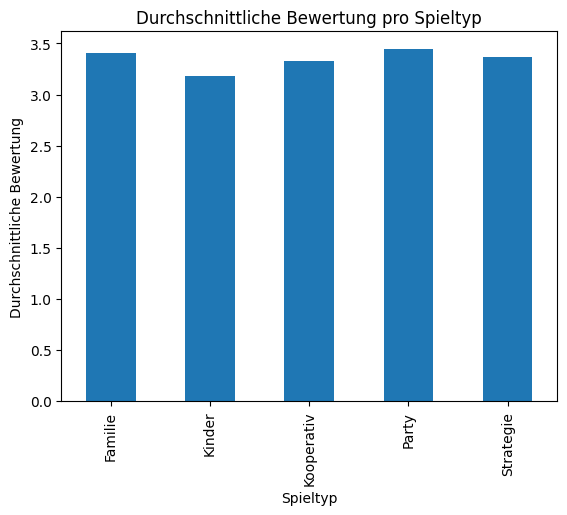

In [40]:
# Ihre Lösung

rating_by_typ = df.groupby("Typ")["Rating"].mean()

rating_by_typ.plot.bar()
plt.title("Durchschnittliche Bewertung pro Spieltyp")
plt.xlabel("Spieltyp")
plt.ylabel("Durchschnittliche Bewertung")

#### Bewertungen pro Jahr (4 Punkte)
*Nehmen die Anzahl Bewertungen über die Zeit zu oder ab?*

Es soll analysiert werden, ob seit Beginn der Bewertungen die Anzahl eher zu- oder eher abnimmt. 
<div class="alert alert-block alert-info">
    
Erstellen Sie zu diesem Zweck ein **Liniendiagramm**, das die Anzahl Bewertungen pro Jahr darstellt. Schreiben Sie anschließend die Antwort sowie die Einschätzung zu Regeln/Richtlinien in die untenstehende Raw-Zelle.
</div>

In [ ]:
# Ihre Lösung

#### Altersgruppen pro Typ (4 Punkte)
*Welcher Spiele-Typ ist für die wenigsten Altersgruppen geeignet?*

Gesucht ist der Typ, für den am wenigsten unterschiedliche Altersgruppen angegeben wurden. 
<div class="alert alert-block alert-info">
    
Erstellen Sie zu diesem Zweck ein **Kreisdiagramm pro Typ**. Schreiben Sie anschließend die Antwort sowie die Einschätzung zu Regeln/Richtlinien in die untenstehende Raw-Zelle.
</div>

In [48]:
# Ihre Lösung

altersempfehlung_by_typ = df.groupby("Typ")["Altersempfehlung"].unique()
altersempfehlung_by_typ

Typ
Familie                 [6+, 10+]
Kinder                       [6+]
Kooperativ    [12+, 16+, 10+, 6+]
Party         [16+, 10+, 6+, 12+]
Strategie              [16+, 12+]
Name: Altersempfehlung, dtype: object

#### Spiele-Werbung (4 Punkte)
Eines der Fenster soll neu dekoriert werden und hier ein Spiel ausgestellt werden - welches soll das sein?

<div class="alert alert-block alert-info">
    
Wählen Sie aus den Spielen eines aus, das im Fenster ausgestellt werden soll. Schreiben Sie den Namen des Spiels in die untenstehende Raw-Zelle. Wichtig: Begründen Sie Ihre Auswahl!
</div>

In [ ]:
# Platz für Analysen

<div class="alert alert-block alert-danger">

Diese Zelle bitte auf keinen Fall löschen, da der Seitenumbruch für die Korrektur benötigt wird.
    
\newpage

</div>

## Aufgabe 3 - Big Data Analysis (15 Punkte)
Das Spiele-Café möchte sich nun auch der internationalen Brettspielevereinigung (IBGSA) anschließen, die Bewertungen aus Spiele-Cafés weltweit zusammenträgt, um Analysen vorzunehmen und Trends zu erkennen. Hierfür bekommen Sachin und Sumaya Zugang zu einem Hadoop-Cluster, in dem Brettspiele-Daten verwaltet werden. Dieses ist mit insgesamt 256 GB RAM und 75 Kernen ausgestattet.

### Aufgabe 3.1 Daten einlesen (4 Punkte)
Im Folgenden ist ein Ausschnitt des Tree des vom HDFS der IBGSA abgebildet (links) sowie ein Ausschnitt des Tree lokalen Dateisystems des Spiele-Cafés (rechts). Beide Trees beginnen im Root-Verzeichnis (`/`):

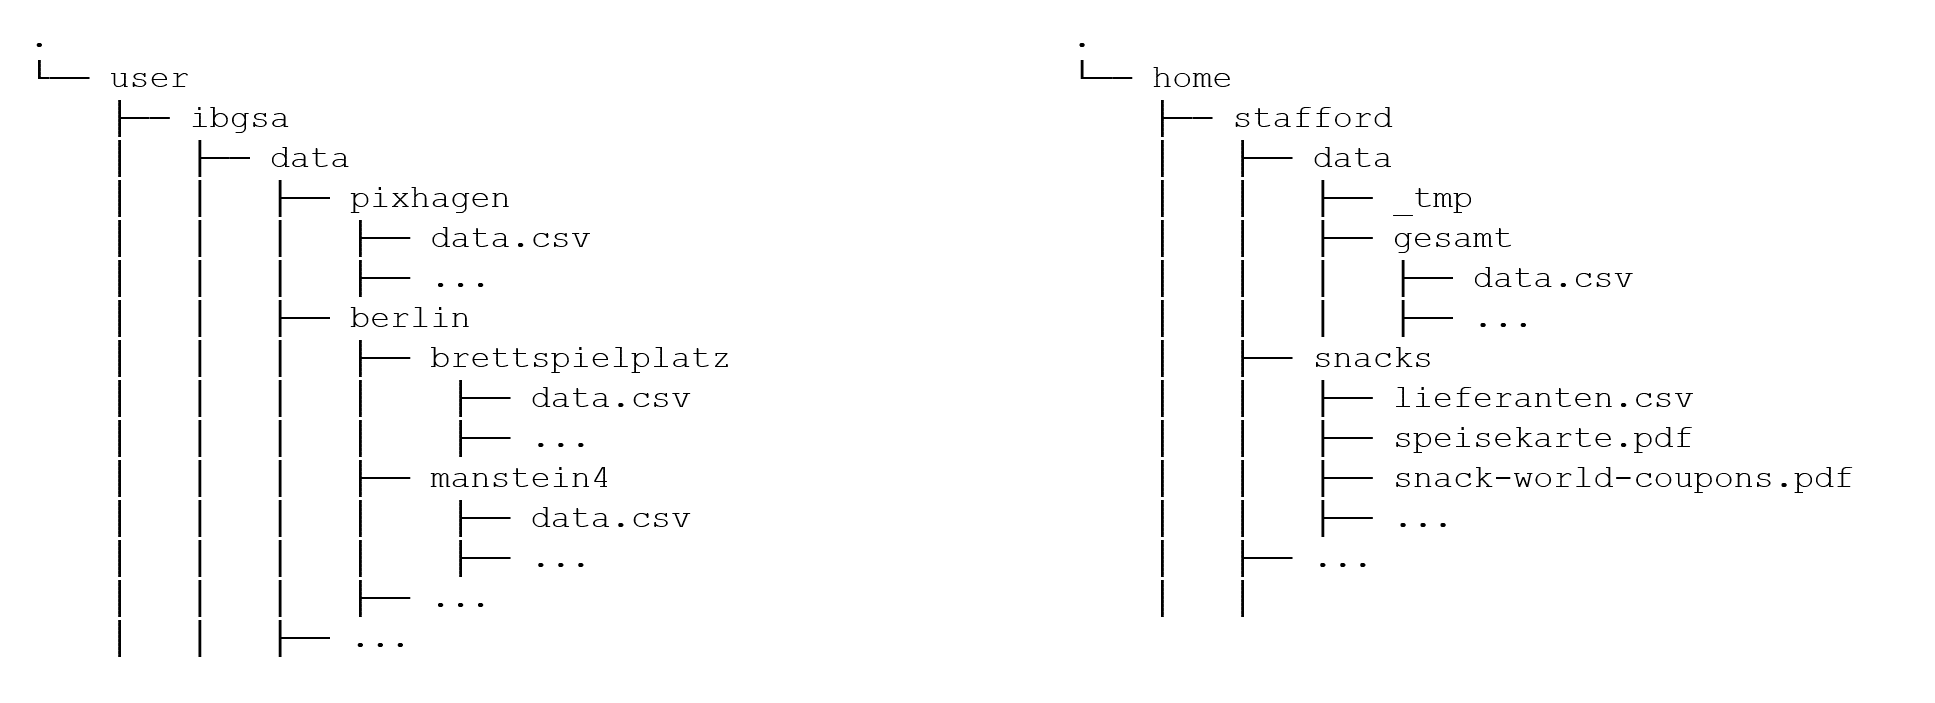

Sachin und Sumaya haben die SparkSession sowie den SparkContext wie folgt erstellt (alle benötigten Imports sind bereits erfolgt):
```python
spark = SparkSession.builder \
    .master("yarn") \
    .appName("best-board-games") \
    .getOrCreate()
sc = spark.sparkContext

```

Betrachten Sie nun die untenstehenden Code-Zellen sowie Ausgaben.

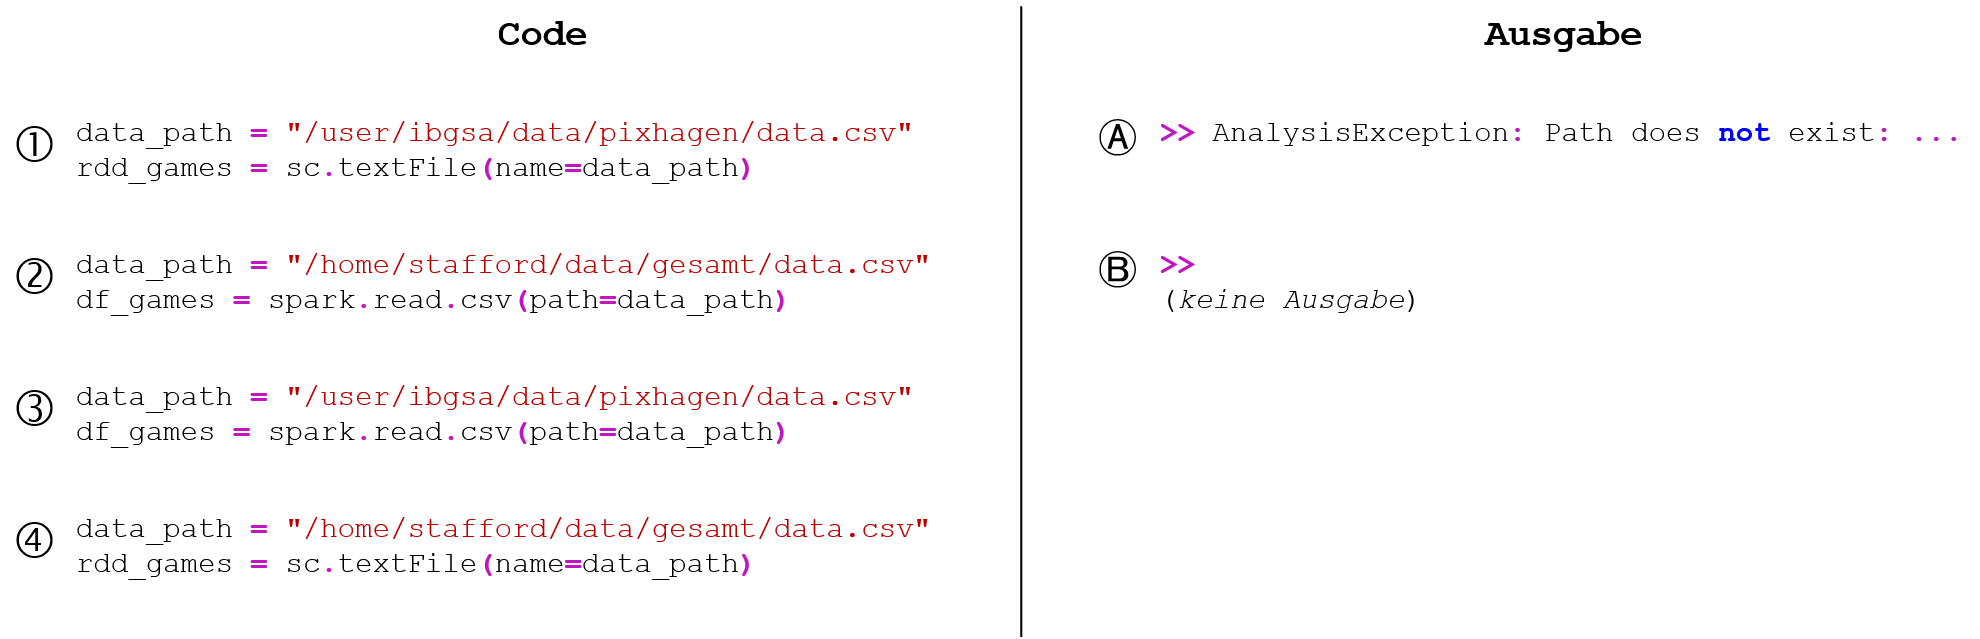

<div class="alert alert-block alert-info">
    
Ordnen Sie den Code-Zellen *1* bis *4* jeweils entweder die Ausgabe *A* (= Fehler) oder *B* (= keine Ausgabe) zu. Geben Sie bei jeder Zuordnung eine kurze Begründung (Stichpunkte sind ausreichend) an.
</div>

### Aufgabe 3.2 Fehlerfall (3 Punkte)

Sachin und Sumaya wollen nun erste Analysen mit Spark machen und schreiben dafür den folgenden Code:

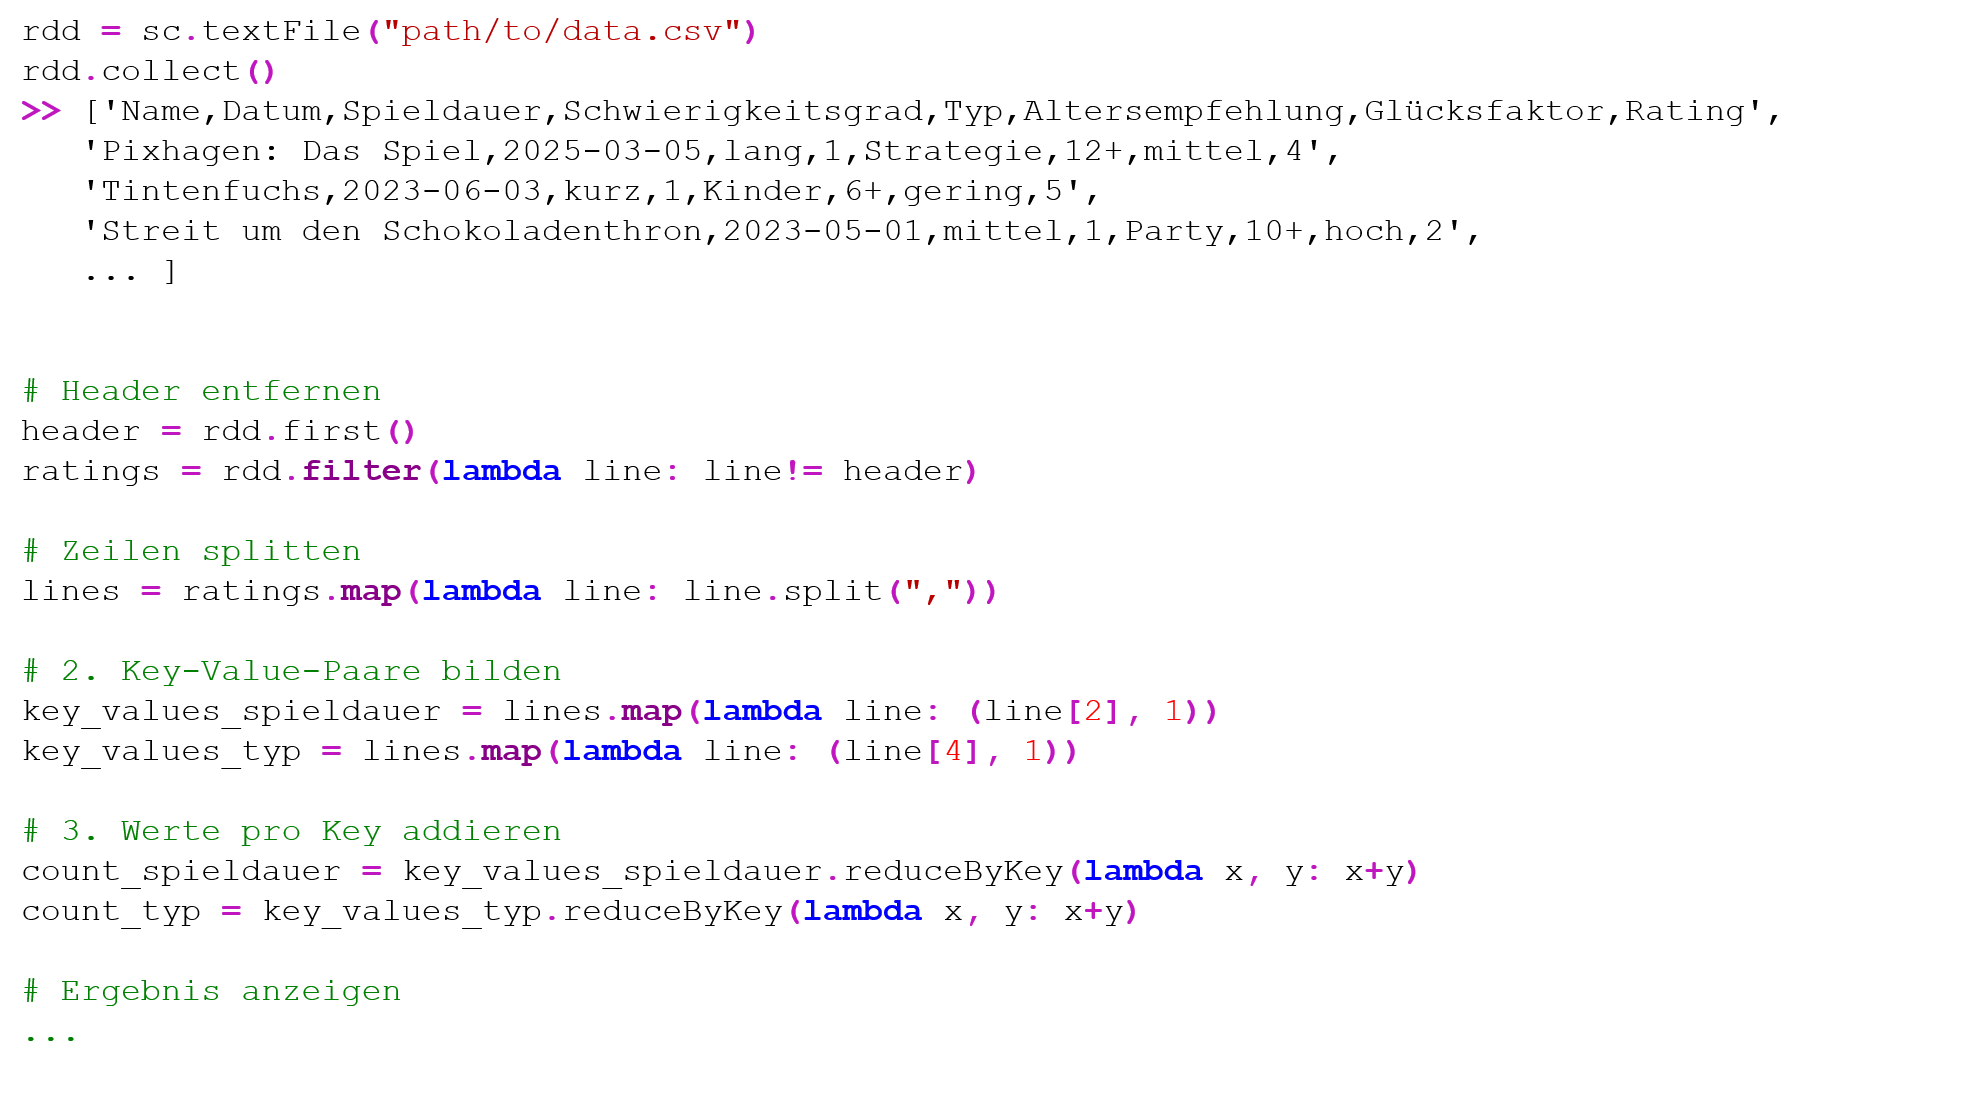

Im Hadoop-Cluster kommt es bei der Berechnung des RDD `key_values_typ` zu einem Fehlerfall, weshalb das RDD neu berechnet werden muss. Aus welchem RDD wird `key_values_typ` nun neu berechnet? Welche der fünf Eigenschaften von RDDs liegt dem zugrunde?

<div class="alert alert-block alert-info">
    
- Geben Sie den Namen des RDDs an, aus dem `key_values_typ` neu berechnet wird.
- Nennen Sie die zugrundeliegende Eigenschaft und beschreiben sie diese in einem Satz.
</div>

### Aufgabe 3.2 Ressourcenverbrauch (8 Punkte)
Im Folgenden ist der Inhalt der Datei `spark-defaults.conf` zu sehen:
```
spark.driver.cores 2
spark.driver.memory 2G
spark.dynamicAllocation.enabled false
spark.executor.memory 3G
spark.yarn.am.memory 1.5G
spark.executor.memoryOverhead 0.5G
spark.executor.cores 4
spark.yarn.am.cores 2
spark.executor.instances 12
spark.yarn.am.memoryOverhead 1G
```

In einem Jupyter Notebook starten Sachin und Sumaya mit der folgenden Zelle eine SparkSession:
```python
# SparkSession erstellen
spark = SparkSession.builder \
    .master("yarn") \
    .appName("best-board-games") \
    .config("spark.executor.instances", "6") \
    .config("spark.yarn.am.memory", "2G") \
    .getOrCreate()

# SparkContext
sc = spark.sparkContext
```


<div class="alert alert-block alert-info">
    
Berechnen Sie den Ressourcen-Verbrauch (Memory und Cores) der Spark-Anwendung. Geben Sie dabei Ihren Rechenweg an.
</div>

In [36]:
2.5 + 12 * 3.5

44.5